In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pickle

In [4]:
sem_green_yellow_bound = 0.5  # m/s2
sem_yellow_red_bound = 1.5  # m/s2

sem_green_yellow_bound_norm, sem_yellow_red_bound_norm = -.766, .326


with open('sem_green_yellow_speeds_1.pkl', 'rb') as file:
    sem_green_yellow_speeds_1 = pickle.load(file)
with open('sem_yellow_red_speeds_1.pkl', 'rb') as file:
    sem_yellow_red_speeds_1 = pickle.load(file)
    
# with open('sem_green_yellow_speeds_2.pkl', 'rb') as file:
#     sem_green_yellow_speeds_2 = pickle.load(file)
# with open('sem_yellow_red_speeds_2.pkl', 'rb') as file:
#     sem_yellow_red_speeds_2 = pickle.load(file)

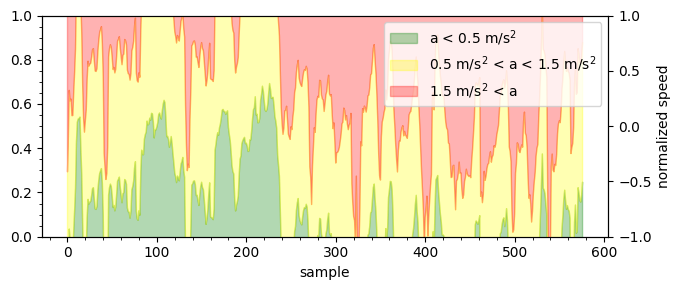

In [11]:
indices = np.arange(len(sem_green_yellow_speeds_1))
fig, ax = plt.subplots(1, 1, figsize=(7,3), sharex='col')

ax.minorticks_on()
ax_twin = ax.twinx()


ax_twin.fill_between(indices, -10, sem_green_yellow_speeds_1, color='green', alpha=0.3, 
                label=f'a < {sem_green_yellow_bound} m/s$^2$')

ax_twin.fill_between(indices, sem_green_yellow_speeds_1, sem_yellow_red_speeds_1, color='yellow', alpha=0.3, 
                label=f'{sem_green_yellow_bound} m/s$^2$ < a < {sem_yellow_red_bound} m/s$^2$')

ax_twin.fill_between(indices, sem_yellow_red_speeds_1, max(sem_yellow_red_speeds_1) + 10, color='red', alpha=0.3, 
                label=f'{sem_yellow_red_bound} m/s$^2$ < a')


ax_twin.legend(loc='upper right', )
ax.set_xlabel('sample')
ax_twin.set_ylabel('normalized speed')
ax_twin.set_ylim([-1, 1])
plt.tight_layout()
plt.savefig('semaphore'+'.pdf')
plt.show()